<a href="https://colab.research.google.com/github/himanshu-js/data_analyst_internship_project/blob/main/Week2/Python_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the Dataset

In [2]:
df = pd.read_csv('/content/SQL_Sales_Dataset_200_Rows.xlsx - Sheet1.csv')

## Information About the Data

In [3]:
df.head()

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
0,1000,Caleb Davis,2025-01-31,Clothing,Jeans,Jeans Try,2,1197,2394,West
1,1001,Misty Herrera,2025-05-05,Clothing,Jeans,Jeans New,9,1509,13581,South
2,1002,Rick Soto,2025-06-09,Clothing,Shoes,Shoes Us,5,1046,5230,East
3,1003,Sean Haas,2025-02-27,Furniture,Desk,Desk Section,10,292,2920,South
4,1004,Ann Hall,2025-06-01,Furniture,Cabinet,Cabinet Center,2,548,1096,North


In [4]:
df.shape

(200, 10)

In [5]:
df.columns

Index(['order_id', 'customer_name', 'order_date', 'category', 'sub_category',
       'product_name', 'quantity', 'unit_price', 'total_price', 'region'],
      dtype='object')

In [6]:
df.dtypes

,0
order_id,int64
customer_name,object
order_date,object
category,object
sub_category,object
product_name,object
quantity,int64
unit_price,int64
total_price,int64
region,object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       200 non-null    int64 
 1   customer_name  200 non-null    object
 2   order_date     200 non-null    object
 3   category       200 non-null    object
 4   sub_category   200 non-null    object
 5   product_name   200 non-null    object
 6   quantity       200 non-null    int64 
 7   unit_price     200 non-null    int64 
 8   total_price    200 non-null    int64 
 9   region         200 non-null    object
dtypes: int64(4), object(6)
memory usage: 15.8+ KB


## Statistical Summary

In [8]:
df.describe()

,order_id,quantity,unit_price,total_price
count,200.000000,200.000000,200.000000,200.000000
mean,1099.500000,4.910000,2421.495000,12100.535000
std,57.879185,3.017853,1464.016187,10915.548067
min,1000.000000,1.000000,79.000000,79.000000
25%,1049.750000,2.000000,1120.000000,3060.000000
50%,1099.500000,5.000000,2373.500000,8912.000000
75%,1149.250000,7.000000,3541.750000,19350.750000
max,1199.000000,10.000000,4997.000000,47940.000000


## Check Null Values

In [9]:
df.isnull()

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

,0
order_id,0
customer_name,0
order_date,0
category,0
sub_category,0
product_name,0
quantity,0
unit_price,0
total_price,0
region,0


## Duplicate Value Remove

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(200, 10)

## Sub Category Sold

In [13]:
item_sold = df['sub_category'].value_counts().reset_index()

item_sold.columns = ['sub_category', 'No of Items']
item_sold


,sub_category,No of Items
0,Chair,19
1,Cabinet,18
2,Snacks,15
3,Bread,14
4,Laptop,14
5,Headphones,13
6,Tablet,13
7,Shoes,12
8,Desk,12
9,Mobile,12


In [14]:
item_sold_sorted = item_sold.iloc[::-1]

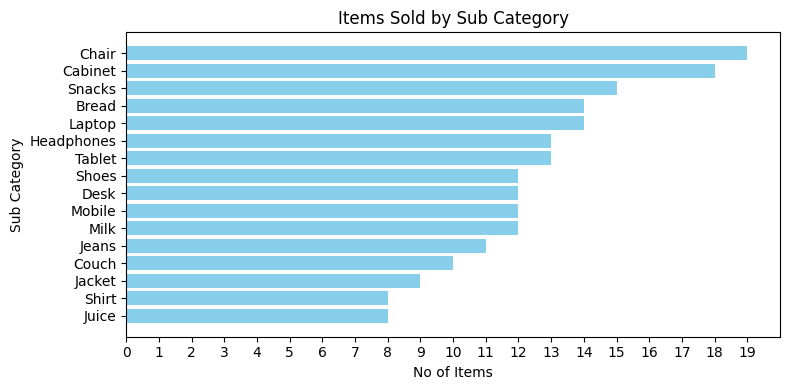

In [40]:
plt.figure(figsize=(8, 4))

bars = plt.barh(item_sold_sorted['sub_category'], item_sold_sorted['No of Items'], color='skyblue')

max_val = item_sold_sorted['No of Items'].max()
plt.xlim(0, max_val + 1)

plt.xticks(np.arange(0, max_val + 1, step=1))

plt.xlabel('No of Items')
plt.ylabel('Sub Category')
plt.title('Items Sold by Sub Category')
plt.tight_layout()
plt.show()


## Region Wise Sales

In [16]:
reg_wise_sal = df['region'].value_counts().reset_index()
reg_wise_sal.columns = ['region', 'total_sales']
reg_wise_sal

,region,total_sales
0,South,66
1,East,51
2,West,43
3,North,40


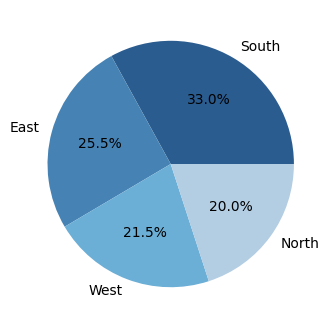

In [43]:
plt.figure(figsize=(8,4))
ocean_colors = ['#2b5c8f', '#4682b4', '#6baed6', '#b3cde3', '#c7e9b4', '#7fcdbb']
plt.pie(reg_wise_sal['total_sales'], labels=reg_wise_sal['region'], autopct='%1.1f%%', colors=ocean_colors)
plt.show()

## Date Column Analysis

In [18]:
count_unq_o_date = df['order_date'].nunique()

print(count_unq_o_date)

124


In [21]:
date_counts = df['order_date'].value_counts().reset_index()
date_counts.head()

,order_date,count
0,2025-06-01,5
1,2025-04-14,4
2,2025-01-17,4
3,2025-05-12,4
4,2025-03-16,3


In [23]:
# duplicated dates dataframe
date_counts_dup_df = date_counts[date_counts['count'] > 1]

In [27]:
date_counts_dup_df.head()

,order_date,count
0,2025-06-01,5
1,2025-04-14,4
2,2025-01-17,4
3,2025-05-12,4
4,2025-03-16,3


## Highest Product Selling Date

In [58]:
highest_selling_date = date_counts_dup_df.head(1)
highest_selling_date

,order_date,count
0,2025-06-01,5


## Top Five Highest Selling Date

In [57]:
top_five_highest_selling_date = date_counts_dup_df.head(5)
top_five_highest_selling_date

,order_date,count
0,2025-06-01,5
1,2025-04-14,4
2,2025-01-17,4
3,2025-05-12,4
4,2025-03-16,3


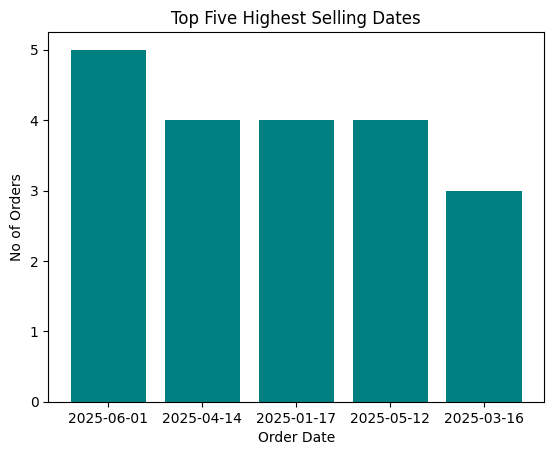

In [45]:
plt.bar(top_five_highest_selling_date['order_date'], top_five_highest_selling_date['count'],color='teal')
plt.xlabel('Order Date')
plt.ylabel('No of Orders')
plt.title('Top Five Highest Selling Dates')
plt.show()

## Category Wise Revenue

In [56]:
category_wise_revenue = df.groupby('category')['total_price'].sum().reset_index()


In [50]:
category_wise_revenue

,category,total_price
0,Clothing,484259
1,Electronics,549302
2,Furniture,714399
3,Grocery,672147


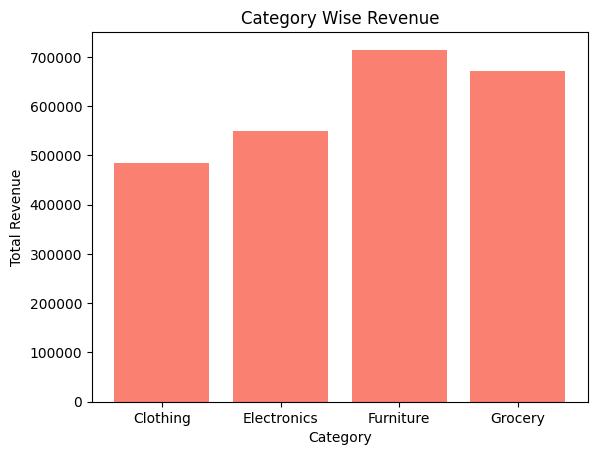

In [54]:
plt.bar(category_wise_revenue['category'], category_wise_revenue['total_price'],color='salmon')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.title('Category Wise Revenue')
plt.show()
#

## Correlation Matrix

In [63]:

# Step 1: Select only numeric columns (integers and floats)
numeric_df = df.select_dtypes(include=['number'])

# Step 2: Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

print(correlation_matrix)


             order_id  quantity  unit_price  total_price
order_id     1.000000 -0.018182    0.102267     0.099480
quantity    -0.018182  1.000000    0.047996     0.655212
unit_price   0.102267  0.047996    1.000000     0.671318
total_price  0.099480  0.655212    0.671318     1.000000
